### Import & Load data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast

DATA_DIR = Path('../data/raw')
train = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8', encoding_errors='replace')
train['labels'] = train['labels'].apply(ast.literal_eval)

LABEL_NAMES = {
    0: 'amusement',    1: 'excitement',  2: 'joy',          3: 'love',
    4: 'desire',       5: 'optimism',    6: 'caring',        7: 'pride',
    8: 'admiration',   9: 'gratitude',  10: 'relief',       11: 'approval',
    12: 'realization', 13: 'surprise',   14: 'curiosity',    15: 'confusion',
    16: 'fear',        17: 'nervousness',18: 'remorse',      19: 'embarrassment',
    20: 'disappointment', 21: 'sadness', 22: 'grief',        23: 'disgust',
    24: 'anger',       25: 'annoyance',  26: 'disapproval',  27: 'neutral'
}


### Chart 1: Label Distribution:

In [3]:
from collections import Counter

label_counts = Counter(label for labels in train['labels'] for label in labels)
label_series = pd.Series({LABEL_NAMES[k]: v for k, v in label_counts.most_common()})


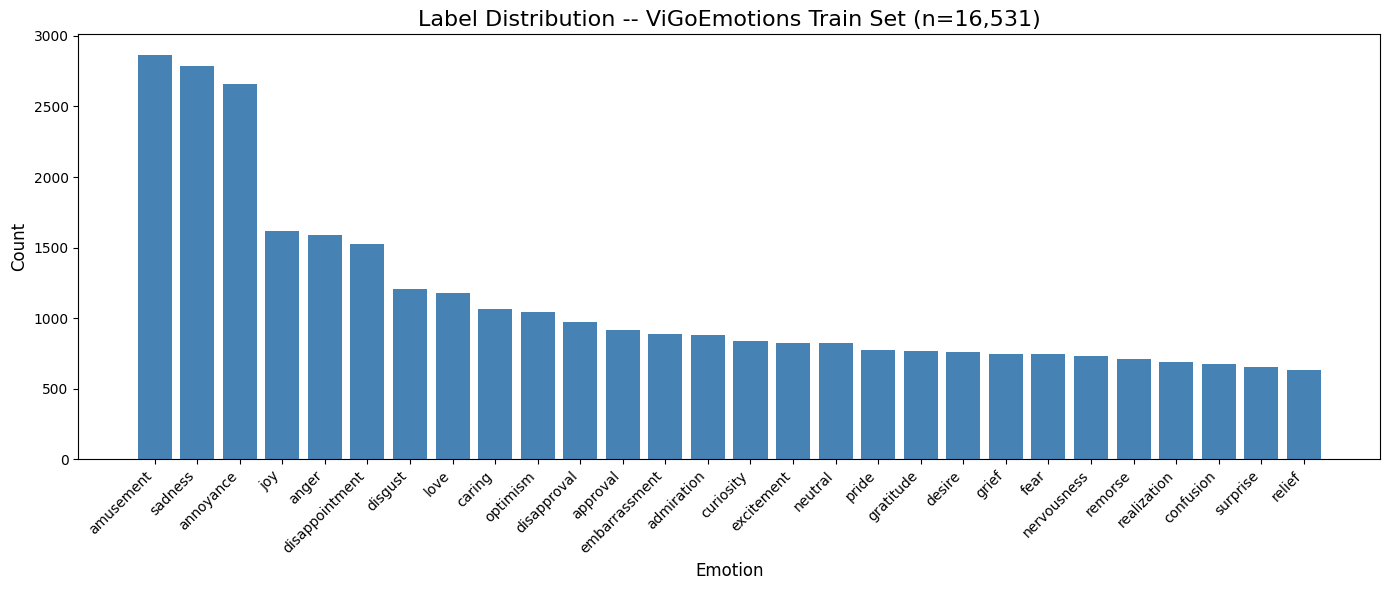

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(label_series.index, label_series.values, color ='steelblue')

ax.set_title('Label Distribution -- ViGoEmotions Train Set (n=16,531)', fontsize=16)
ax.set_xlabel('Emotion', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Nhãn amusement xuất hiện nhiều nhất, relief ít nhất, chênh lệch khoảng 3 lần. Với mức mất cân bằng này, model tối ưu theo accuracy hay F1-weighted có thể đạt số cao nhưng bỏ sót nhãn thiểu số. F1-macro mới là thước đo phản ánh trung thực hiệu suất trên toàn bộ 28 nhãn, vì nó tính trung bình đều tất cả nhãn không phụ thuộc tần suất (RQ3).

### Chart 2: Label Co-occurrence Heatmap

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

mlb = MultiLabelBinarizer(classes=list(range(28)))
binary_matrix = mlb.fit_transform(train['labels'])

co_matrix = binary_matrix.T @ binary_matrix
np.fill_diagonal(co_matrix, 0)

label_names = list(LABEL_NAMES.values())
co_df = pd.DataFrame(co_matrix, index=label_names, columns=label_names)

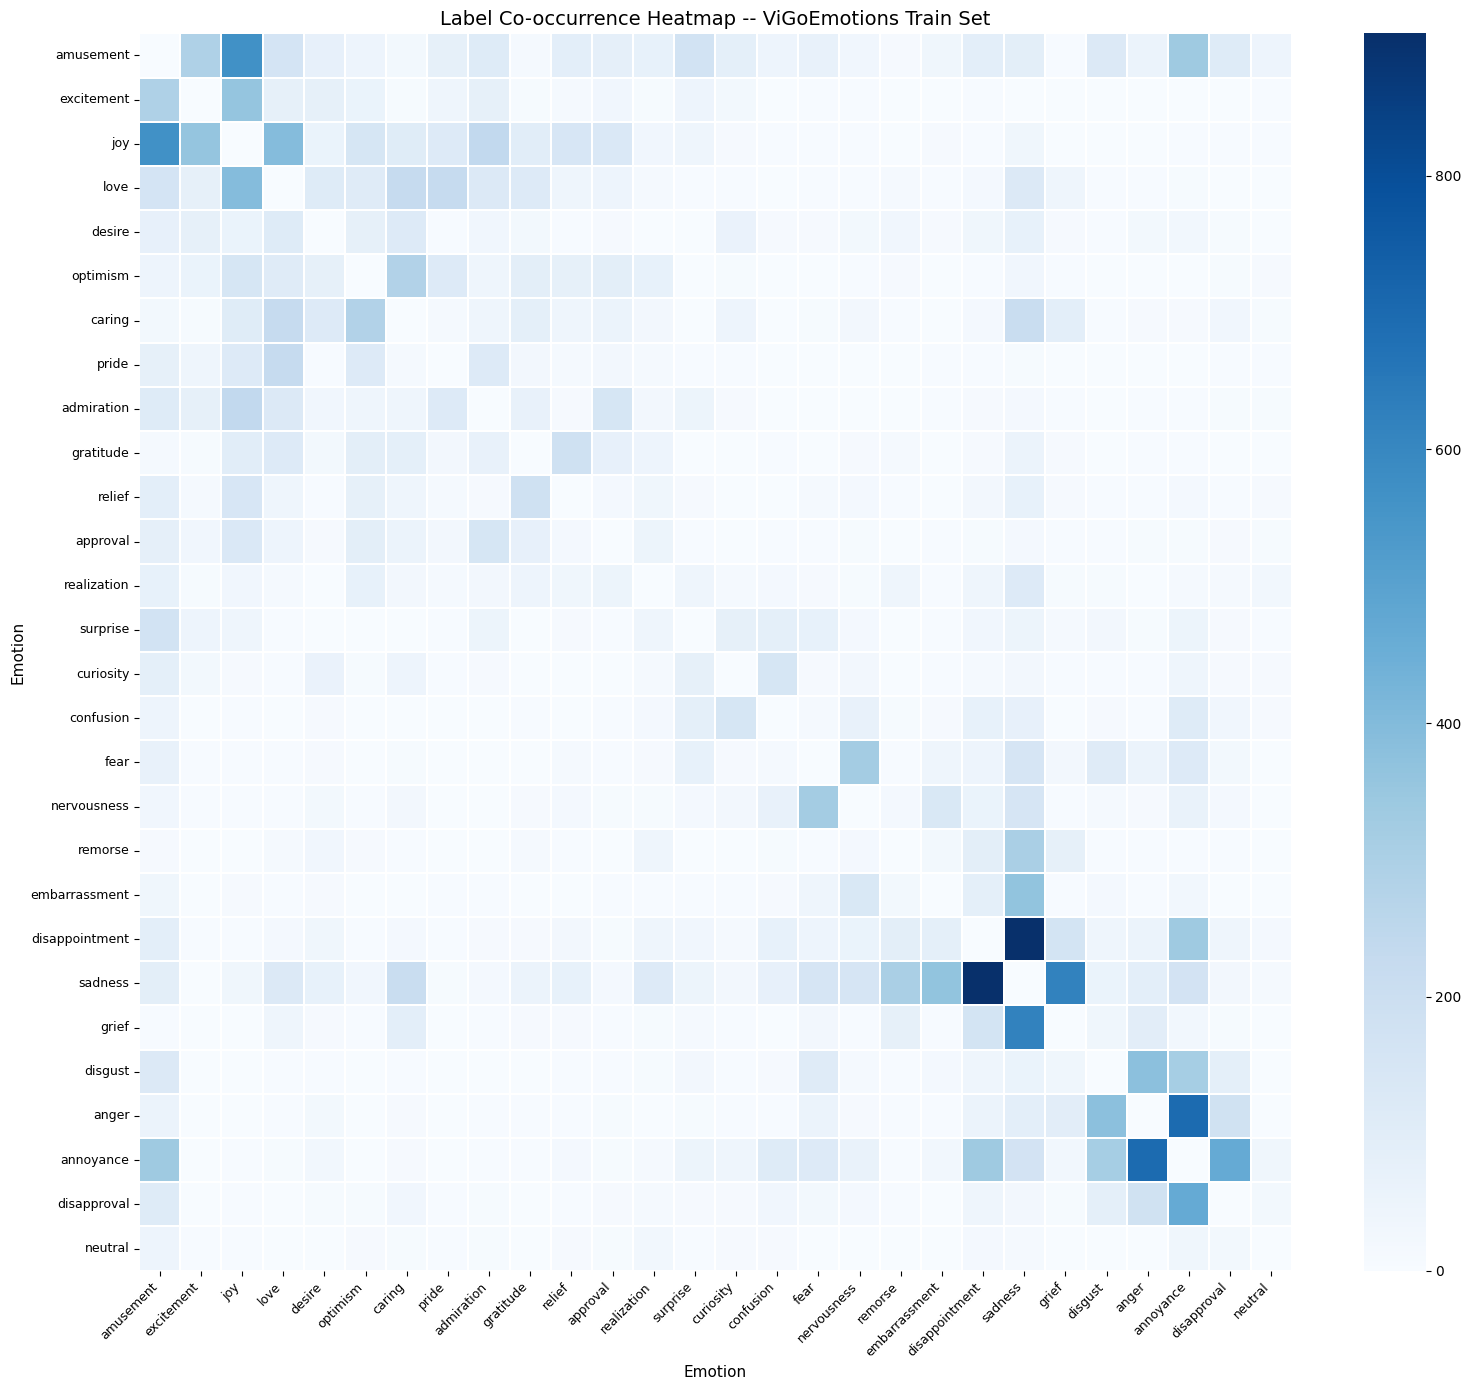

In [ ]:
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(co_df, cmap='Blues', ax=ax, linewidths=0.3)
ax.set_title('Label Co-occurrence Heatmap -- ViGoEmotions Train Set', fontsize=14)
ax.set_xlabel('Emotion', fontsize=11)
ax.set_ylabel('Emotion', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Các cặp nhãn xuất hiện cùng nhau nhiều nhất bao gồm sadness và disappointment, sadness và grief, anger và annoyance. Nhóm cảm xúc tiêu cực có xu hướng hình thành cụm, một câu mang nhãn sadness thường đồng thời mang grief hoặc disappointment. Đây là label correlation. Model OneVsRest trong baseline xử lý từng nhãn độc lập nên bỏ qua correlation này, có thể bỏ sót nhãn trong cùng cụm khi dự đoán (RQ3).

### Chart 3: Text Length Distribution by Label

In [ ]:
rows = []


for _, r in train.iterrows():
    for lbl in r['labels']:
        rows.append({
            'label_name': LABEL_NAMES[lbl],
            'text_length': len(r['text'])
        })
df_len = pd.DataFrame(rows)

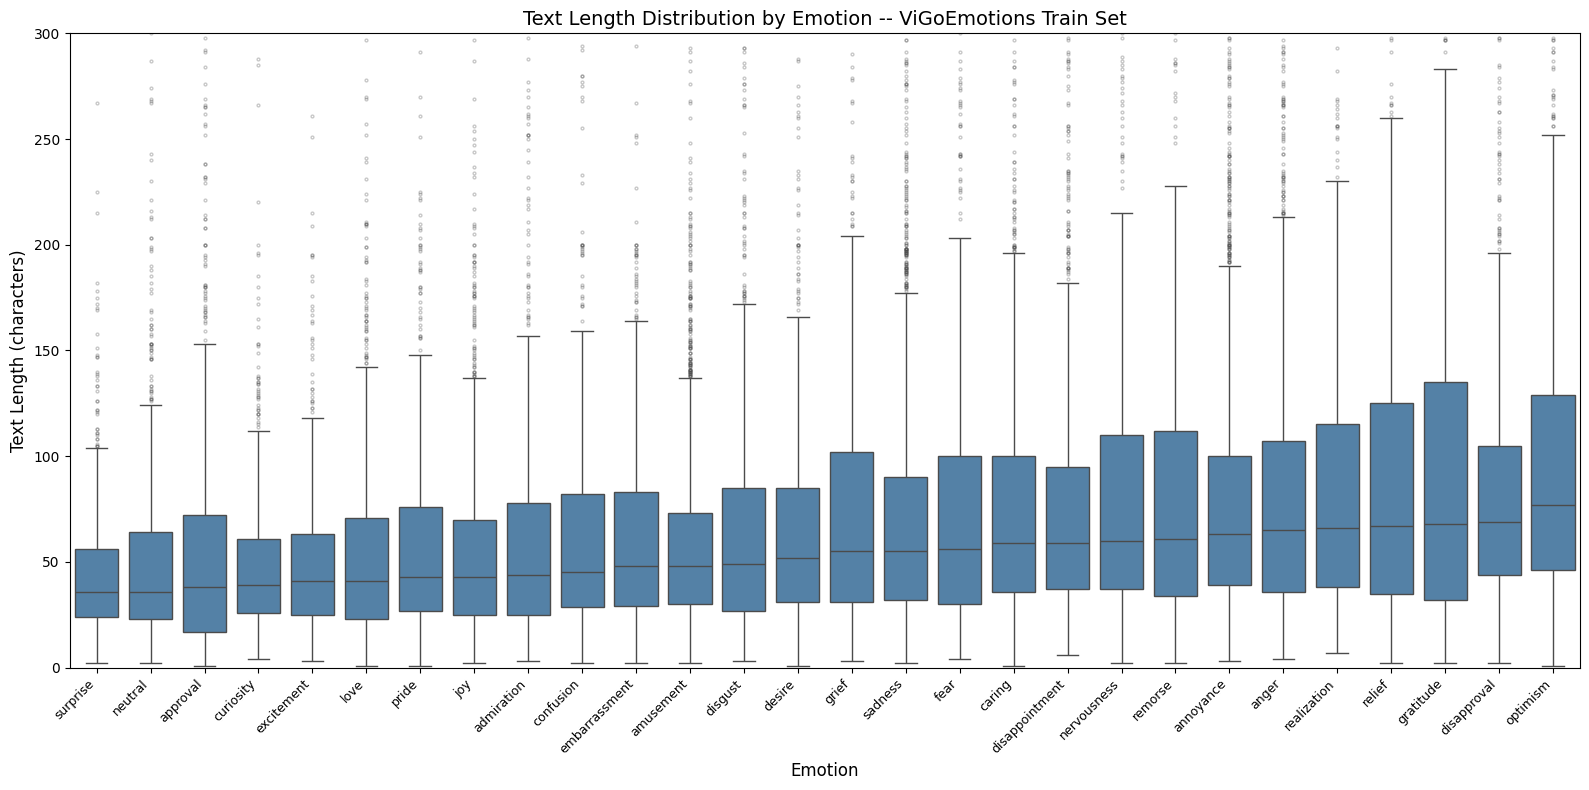

In [35]:
order = df_len.groupby('label_name')['text_length'].median().sort_values().index

fig, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(data=df_len, x='label_name', y='text_length', order=order, ax=ax,
            color='steelblue', flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Text Length Distribution by Emotion -- ViGoEmotions Train Set', fontsize=14)
ax.set_xlabel('Emotion', fontsize=12)
ax.set_ylabel('Text Length (characters)', fontsize=12)
ax.set_ylim(0, 300)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


Nhãn surprise và neutral có median thấp nhất, phần lớn bình luận chỉ dài 20-40 ký tự, phù hợp với kiểu phản ứng ngắn gọn tức thì. Ngược lại, optimism, disapproval và gratitude có median cao hơn rõ rệt, cho thấy người dùng thường giải thích dài hơn khi bày tỏ quan điểm hoặc lòng biết ơn. Nhãn sadness có nhiều outlier phía trên, một số bình luận buồn kéo dài đến hàng trăm ký tự, có thể là dạng tâm sự. Độ dài văn bản là đặc trưng có giá trị phân biệt nhóm nhãn, đặc biệt giữa cảm xúc phản ứng tức thì và cảm xúc cần diễn đạt (RQ1).